Original data (first 5 rows):
        close        high         low        open     volume
0  895.026001  899.398010  887.007996  898.171997   86728400
1  921.789001  927.367004  895.534973  895.549011  111158000
2  924.672974  937.525024  897.564026  922.205017  116573000
3  921.012024  928.265991  916.737976  925.499023   73588600
4  892.687012  924.145020  892.286011  910.677002  111349000


<ipython-input-29-756cae45bfcb>:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by="date", inplace=True)
<ipython-input-29-756cae45bfcb>:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[features] = df[features].interpolate(method='linear')
<ipython-input-29-756cae45bfcb>:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-vie

✅ Scaler saved successfully!
Training data X shape: (1986, 50, 16)
Training data y shape: (1986, 5)
Epoch 1/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 652ms/step - loss: 8.0946 - val_loss: 4.5760 - learning_rate: 0.0010
Epoch 2/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 654ms/step - loss: 6.1824 - val_loss: 4.2606 - learning_rate: 0.0010
Epoch 3/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 633ms/step - loss: 5.0827 - val_loss: 3.9011 - learning_rate: 0.0010
Epoch 4/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 636ms/step - loss: 4.2467 - val_loss: 3.5243 - learning_rate: 0.0010
Epoch 5/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 629ms/step - loss: 3.8114 - val_loss: 3.2279 - learning_rate: 0.0010
Epoch 6/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 632ms/step - loss: 3.2310 - val_loss: 2.9155 - learning_rate: 0.0010
Epoch 7/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 634ms/step - loss: 2.8445 - val_loss: 2.6210 - learning_rate: 0.0010
Epoch 8/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 672ms/step - loss: 2.5685 - val_loss: 2.4346 - learning_rate: 0.0010
Epoc

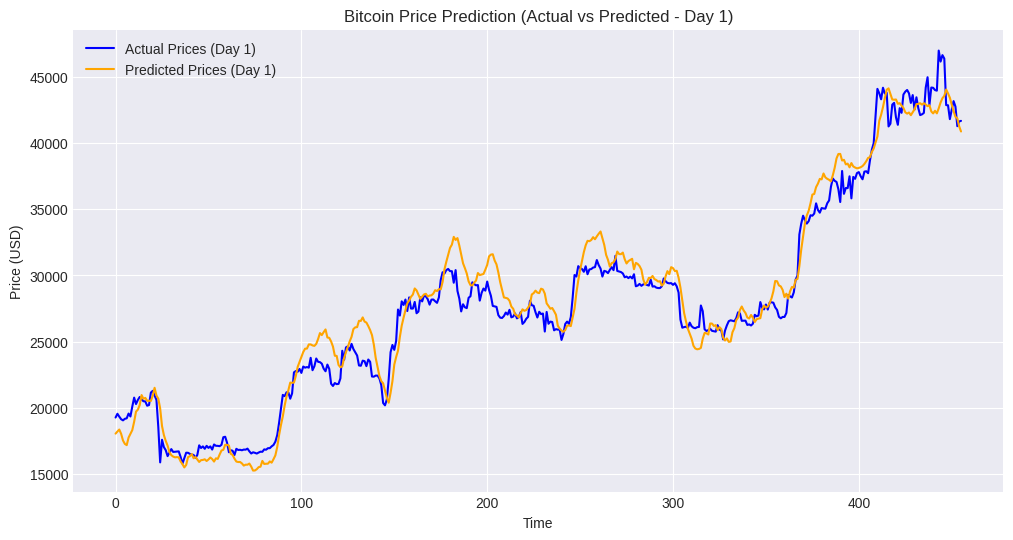

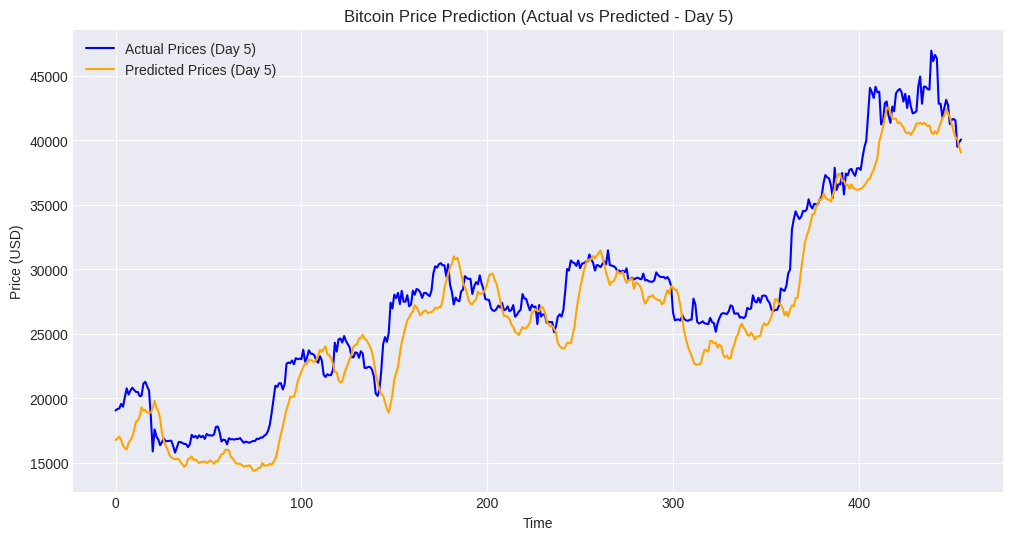

----------------------------------------
Evaluation Metrics for Each Future Day:
----------------------------------------

Day 1:
  MSE: 2207474.32, RMSE: 1485.76, MAE: 1183.01, MAPE: 4.48%, R2: 0.96

Day 2:
  MSE: 3091384.39, RMSE: 1758.23, MAE: 1420.11, MAPE: 5.70%, R2: 0.95

Day 3:
  MSE: 3567870.47, RMSE: 1888.88, MAE: 1471.34, MAPE: 5.61%, R2: 0.94

Day 4:
  MSE: 4626714.90, RMSE: 2150.98, MAE: 1751.16, MAPE: 6.63%, R2: 0.92

Day 5:
  MSE: 5939666.22, RMSE: 2437.14, MAE: 1946.90, MAPE: 7.45%, R2: 0.90
----------------------------------------
Average Metrics (across all days):
----------------------------------------
Average MSE: 3886622.06
Average RMSE: 1944.20
Average MAE: 1554.50
Average MAPE: 5.97%
Average R2: 0.93
✅ Multi-step model (5 days) saved successfully!


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Input, Layer, BatchNormalization
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler, ReduceLROnPlateau
from tensorflow.keras.regularizers import L2
import matplotlib.pyplot as plt
import joblib

features = [
    'close', 'high', 'low', 'open', 'volume',
    'positive_ratio', 'negative_ratio', 'neutral_ratio',
    'SMA_20', 'EMA_20', 'RSI', 'Bollinger_Upper', 'Bollinger_Lower', 'Volatility',
    'SMA_50', 'SMA_100'
]

PREDICTION_HORIZON = 5

class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(Attention, self).build(input_shape)

    def call(self, x):
        et = tf.nn.tanh(tf.matmul(x, self.W) + self.b)
        at = tf.nn.softmax(et, axis=1)
        at = tf.transpose(at, perm=[0, 2, 1])
        output = tf.matmul(at, x)
        return tf.squeeze(output, axis=1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

def load_data():
    df = pd.read_csv('bitcoin_processed_with_features (1).csv')
    df['date'] = pd.to_datetime(df['date'])

    df['SMA_50'] = df['close'].rolling(window=50).mean()
    df['SMA_100'] = df['close'].rolling(window=100).mean()

    df.fillna(0, inplace=True)

    return df

def preprocess_data(df, scaler, sequence_length=50, prediction_horizon=PREDICTION_HORIZON, fit_scaler=True):
    df.sort_values(by="date", inplace=True)
    df.reset_index(drop=True, inplace=True)

    df[features] = df[features].interpolate(method='linear')

    if fit_scaler:
        df[features] = scaler.fit_transform(df[features])
    else:
        df[features] = scaler.transform(df[features])

    X, y = [], []
    for i in range(sequence_length, len(df) - prediction_horizon + 1):
        X.append(df[features].iloc[i-sequence_length:i].values)
        y.append(df['close'].iloc[i:i+prediction_horizon].values)

    return np.array(X), np.array(y)

def build_lstm_model(units, dropout_rate, learning_rate, input_shape, output_steps=PREDICTION_HORIZON):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(units, return_sequences=True, kernel_regularizer=L2(0.01)),
        BatchNormalization(),
        Dropout(dropout_rate),
        LSTM(units, return_sequences=False, kernel_regularizer=L2(0.01)),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(64, activation='relu'),
        Dropout(dropout_rate),
        Dense(output_steps)
    ])
    model.compile(optimizer=tf.keras.optimizers.Nadam(learning_rate=learning_rate), loss='mean_squared_error')
    return model

def plot_predictions(actual_prices, predicted_prices, days_ahead=1):

    if days_ahead < 1 or days_ahead > actual_prices.shape[1]:
        raise ValueError(f"days_ahead must be between 1 and {actual_prices.shape[1]}")

    day_index = days_ahead - 1

    plt.figure(figsize=(12, 6))
    plt.plot(actual_prices[:, day_index], label=f"Actual Prices (Day {days_ahead})", color="blue")
    plt.plot(predicted_prices[:, day_index], label=f"Predicted Prices (Day {days_ahead})", color="orange")
    plt.title(f"Bitcoin Price Prediction (Actual vs Predicted - Day {days_ahead})")
    plt.xlabel("Time")
    plt.ylabel("Price (USD)")
    plt.legend()
    plt.grid(True)
    plt.show()

def evaluate_model(actual_prices, predicted_prices):
    """
    Evaluate the model for each future time step
    """
    results = {}
    prediction_horizon = actual_prices.shape[1]

    print("-" * 40)
    print("Evaluation Metrics for Each Future Day:")
    print("-" * 40)

    all_metrics = {'MSE': [], 'RMSE': [], 'MAE': [], 'MAPE': [], 'R2': []}

    for i in range(prediction_horizon):
        actual = actual_prices[:, i]
        predicted = predicted_prices[:, i]

        non_zero_actual_indices = actual != 0
        actual_safe = actual[non_zero_actual_indices]
        predicted_safe = predicted[non_zero_actual_indices]

        if len(actual_safe) == 0:
            print(f"\nDay {i+1}: No non-zero actual values, skipping MAPE calculation.")
            mape = np.nan
        else:
            abs_error_ratio = np.abs((actual_safe - predicted_safe) / actual_safe)
            mape = np.mean(abs_error_ratio) * 100

        mse = mean_squared_error(actual, predicted)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(actual, predicted)
        r2 = r2_score(actual, predicted)

        print(f"\nDay {i+1}:")
        print(f"  MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%, R2: {r2:.2f}")

        results[f'day_{i+1}'] = {"MSE": mse, "RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2}
        all_metrics['MSE'].append(mse)
        all_metrics['RMSE'].append(rmse)
        all_metrics['MAE'].append(mae)
        if not np.isnan(mape):
            all_metrics['MAPE'].append(mape)
        all_metrics['R2'].append(r2)

    print("-" * 40)
    print("Average Metrics (across all days):")
    print("-" * 40)

    avg_mse = np.mean(all_metrics['MSE'])
    avg_rmse = np.mean(all_metrics['RMSE'])
    avg_mae = np.mean(all_metrics['MAE'])
    avg_mape = np.mean(all_metrics['MAPE']) if all_metrics['MAPE'] else np.nan
    avg_r2 = np.mean(all_metrics['R2'])

    print(f"Average MSE: {avg_mse:.2f}")
    print(f"Average RMSE: {avg_rmse:.2f}")
    print(f"Average MAE: {avg_mae:.2f}")
    print(f"Average MAPE: {avg_mape:.2f}%")
    print(f"Average R2: {avg_r2:.2f}")

    results['average'] = {"MSE": avg_mse, "RMSE": avg_rmse, "MAE": avg_mae, "MAPE": avg_mape, "R2": avg_r2}

    return results

if __name__ == "__main__":
    merged_data = load_data()

    print("Original data (first 5 rows):")
    print(merged_data[['close', 'high', 'low', 'open', 'volume']].head())

    train_size = int(len(merged_data) * 0.8)
    train_data = merged_data[:train_size]
    test_data = merged_data[train_size:]

    scaler = MinMaxScaler(feature_range=(0, 1))

    X_train, y_train = preprocess_data(train_data, scaler, sequence_length=50, prediction_horizon=PREDICTION_HORIZON, fit_scaler=True)
    X_test, y_test = preprocess_data(test_data, scaler, sequence_length=50, prediction_horizon=PREDICTION_HORIZON, fit_scaler=False)

    joblib.dump(scaler, 'bitcoin_scaler_multi_step.save')

    input_shape = (X_train.shape[1], X_train.shape[2])
    print(f"Training data X shape: {X_train.shape}")
    print(f"Training data y shape: {y_train.shape}")

    best_params = {'units': 256, 'dropout_rate': 0.5, 'learning_rate': 0.001, 'batch_size': 64}

    best_model = build_lstm_model(
        units=best_params['units'],
        dropout_rate=best_params['dropout_rate'],
        learning_rate=best_params['learning_rate'],
        input_shape=input_shape,
        output_steps=PREDICTION_HORIZON
    )

    history = best_model.fit(
        X_train, y_train,
        epochs=150,
        batch_size=best_params['batch_size'],
        validation_split=0.2,
        verbose=1,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)
        ]
    )

    predicted_prices_scaled = best_model.predict(X_test)


    num_test_samples = X_test.shape[0]
    num_features = X_train.shape[2]

    predicted_reshaped = predicted_prices_scaled.reshape(-1, 1)

    dummy_predicted = np.zeros((predicted_reshaped.shape[0], num_features))
    dummy_predicted[:, 0] = predicted_reshaped[:, 0]

    inversed_predicted_dummy = scaler.inverse_transform(dummy_predicted)

    predicted_prices = inversed_predicted_dummy[:, 0].reshape(num_test_samples, PREDICTION_HORIZON)

    y_test_reshaped = y_test.reshape(-1, 1)
    dummy_actual = np.zeros((y_test_reshaped.shape[0], num_features))
    dummy_actual[:, 0] = y_test_reshaped[:, 0]
    inversed_actual_dummy = scaler.inverse_transform(dummy_actual)
    y_test_rescaled = inversed_actual_dummy[:, 0].reshape(num_test_samples, PREDICTION_HORIZON)

    print("Predictions (first 5 values):")
    print(predicted_prices[:5])

    print("Rescaled actual values (first 5 values):")
    print(y_test_rescaled[:5])

    plot_predictions(y_test_rescaled, predicted_prices, days_ahead=1)  # Next day
    plot_predictions(y_test_rescaled, predicted_prices, days_ahead=5)  # Day 5

    metrics = evaluate_model(y_test_rescaled, predicted_prices)

    best_model.save(f"bitcoin_price_prediction_multi_step_{PREDICTION_HORIZON}day_model.keras")
